<a href="https://colab.research.google.com/github/Shinyhunter95/Masters-Project/blob/main/AR(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

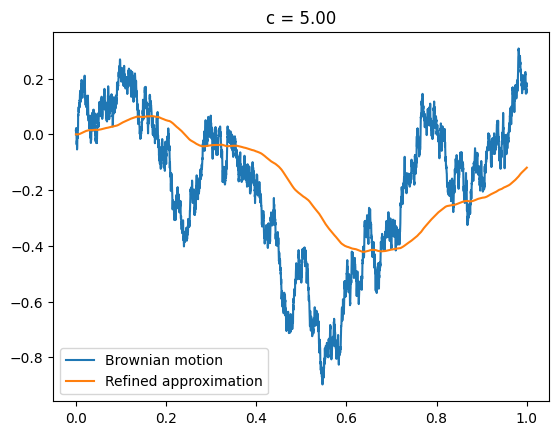

sup |W(t)| = 0.897409139865374
sup |X(t)| = 0.42155549178169216
sup |OU term| 0.5931162191273796


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000

a = 5.0 # This determines c
rho = 1 - a/N

c = N * np.log(1/rho)

# time grid
t = np.linspace(0, 1, N)

# ---------------------------------
# Brownian motion
# ---------------------------------

dW = np.random.normal(0, 1/np.sqrt(N), N)
W = np.cumsum(dW)

# ---------------------------------
# OU correction term
# ---------------------------------

OU_term = np.zeros(N)

for k in range(N):

    tk = t[k]

    kernel = np.exp(-c * (tk - t[:k+1]))

    OU_term[k] = np.sum(kernel * dW[:k+1])

# ---------------------------------
# Approximation process
# ---------------------------------

X = W - OU_term

# ---------------------------------
# Plot
# ---------------------------------

plt.plot(t, W, label='Brownian motion')
plt.plot(t, X, label='Refined approximation')

plt.legend()
plt.title(f'c = {c:.2f}')
plt.show()

print("sup |W(t)| =", np.max(np.abs(W)))
print("sup |X(t)| =", np.max(np.abs(X)))
print("sup |OU term|", np.max(np.abs(OU_term)))